In [1]:
import numpy as np
from best_worst_tradeoff import bwt, consistency_check
from auxiliary import import_criteria
from IPython.display import display

In [2]:
# Salary, Paid Leave, Bonus
worst_comparison_results = [1700, 3, np.nan]
best_comparison_results = [np.nan, 1800, 1700]

In [3]:
criteria = import_criteria("criteria.csv")
display(criteria)


{'Salary': {'min': 1200.0,
  'max': 2000.0,
  'unit': '€',
  'value_function': <function auxiliary.<lambda>(x)>},
 'Paid Leave': {'min': 2.0,
  'max': 10.0,
  'unit': 'days',
  'value_function': <function auxiliary.<lambda>(x)>},
 'Bonus': {'min': 0.0,
  'max': 5000.0,
  'unit': '€',
  'value_function': <function auxiliary.<lambda>(x)>}}

In [4]:
result = bwt(criteria, worst_comparison_results, best_comparison_results)
display(result)

Starting optimization...


     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 0.28965517237946387
           x:     Salary: 0.39999999996788543
              Paid Leave: 0.3241379310075357
                   Bonus: 0.27586206902457855
         nit: 2
         jac: [ 0.000e+00  0.000e+00  0.000e+00  1.000e+00]
        nfev: 10
        njev: 2
 multipliers: [ 0.000e+00  2.103e-01  5.000e-01  2.897e-01  2.897e-01
                0.000e+00  0.000e+00  0.000e+00]

In [5]:
result = bwt(criteria, worst_comparison_results, best_comparison_results, False)
display(result)

Starting optimization...


     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 1.0500000000000222
           x:     Salary: 0.40411487849118527
              Paid Leave: 0.3222608239908235
                   Bonus: 0.2786999161766755
         nit: 4
         jac: [ 0.000e+00  0.000e+00  0.000e+00  1.000e+00]
        nfev: 21
        njev: 4
 multipliers: [ 0.000e+00  5.000e-01  5.000e-01  0.000e+00  0.000e+00
                0.000e+00  0.000e+00  0.000e+00]

In [6]:
result_cc = consistency_check(criteria, result, worst_comparison_results, best_comparison_results)
display(result_cc)

{'Salary': {'Weight': np.float64(0.40411487849118527),
  'BC_value': None,
  'WC_value': 0.4},
 'Paid Leave': {'Weight': np.float64(0.3222608239908235),
  'BC_value': 0.6,
  'WC_value': 0.125},
 'Bonus': {'Weight': np.float64(0.2786999161766755),
  'BC_value': 0.4,
  'WC_value': None}}

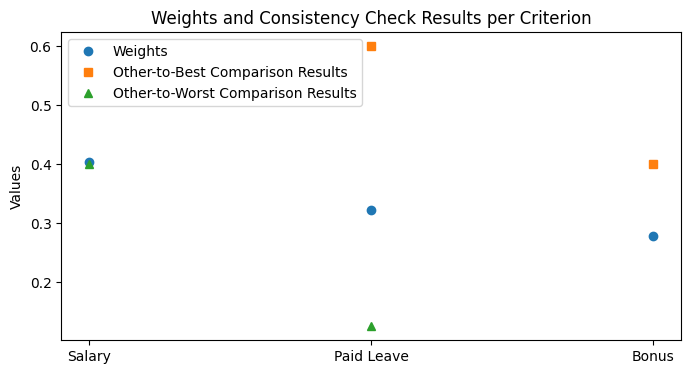

In [8]:
# Plot results for consistency checking
import matplotlib.pyplot as plt

weights = [result_cc[key]["Weight"] for key in result_cc.keys()]
BC_values = [result_cc[key]["BC_value"] for key in result_cc.keys()]
WC_values = [result_cc[key]["WC_value"] for key in result_cc.keys()]

plt.figure(figsize=(8,4))
plt.plot(weights, marker='o', linestyle = '', label='Weights')
plt.plot(BC_values, marker='s', linestyle = '', label='Other-to-Best Comparison Results')
plt.plot(WC_values, marker='^', linestyle = '', label='Other-to-Worst Comparison Results')
plt.xticks(ticks=range(len(result_cc.keys())), labels=result_cc.keys())
plt.ylabel('Values')
plt.title('Weights and Consistency Check Results per Criterion')
plt.legend()
plt.show()

In [16]:
import numpy as np

criteria = {
    'Criterion 1': {
        "min": 0,
        "max": 100,
        "unit": 'units',
        "value_function": "x / 100"
        },
    'Criterion 2': {
        "min": 0,
        "max": 200,
        "unit": 'units',
        "value_function": "x / 200"
        },
    'Criterion 3': {
        "min": 0,
        "max": 300,
        "unit": 'units',
        "value_function": "x / 300"
        },
    'Criterion 4': {
        "min": 0,
        "max": 400,
        "unit": 'units',
        "value_function": "x / 400"
        },
    'Criterion 5': {
        "min": 0,
        "max": 500,
        "unit": 'units',
        "value_function": "x / 500"
        },
    'Criterion 6': {
        "min": 0,
        "max": 600,
        "unit": 'units',
        "value_function": "x / 600"
        },
    'Criterion 7': {
        "min": 0,
        "max": 700,
        "unit": 'units',
        "value_function": "x / 700"
        },
    'Criterion 8': {
        "min": 0,
        "max": 800,
        "unit": 'units',
        "value_function": "x / 800"
        },
    'Criterion 9': {
        "min": 0,
        "max": 900,
        "unit": 'units',
        "value_function": "x / 900"
        }
}

elicitation_first_round_results = {
    'Group 1': {
        'best_comparisons': {
            'Criterion 1': "BEST",
            'Criterion 2': 50,
            'Criterion 3': 53
        },
        'worst_comparisons': {
            'Criterion 1': 23,
            'Criterion 2': 56,
            'Criterion 3': "WORST"
        }
    },
    'Group 2': {
        'best_comparisons': {
            'Criterion 4': "BEST",
            'Criterion 5': 45,
            'Criterion 6': 56
        },
        'worst_comparisons': {
            'Criterion 4': 90,
            'Criterion 5': 34,
            'Criterion 6': "WORST"
        }
    },
    'Group 3': {
        'best_comparisons': {
            'Criterion 7': "BEST",
            'Criterion 8': 21,
            'Criterion 9': 66
        },
        'worst_comparisons': {
            'Criterion 7': 98,
            'Criterion 8': 3,
            'Criterion 9': "WORST"
        }
    }
}

elicitation_second_round_results = {
        'best_of_best': {
            'Criterion 1': 56,
            'Criterion 4': 89,
            'Criterion 7': "BEST"
        },
        'worst_of_best': {
            'Criterion 1': "WORST",
            'Criterion 4': 32,
            'Criterion 7': 3
        },
        'best_of_worst': {
            'Criterion 9': 90,
            'Criterion 6': 23,
            'Criterion 3': "BEST"
        },
        'worst_of_worst': {
            'Criterion 9': "WORST",
            'Criterion 6': 23,
            'Criterion 3': 34
        }
}

In [20]:
def constraints_able(x, criteria, elicitation_first_round_results, elicitation_second_round_results):
    cons = []
    number_of_groups = len(elicitation_first_round_results)
    group_criteria = []
    group_indices = {}
    current_index = 0

    # Map group and criterion names to their indices in x
    for group_name, group_data in elicitation_first_round_results.items():
        criteria_in_group = list(group_data['best_comparisons'].keys())
        group_criteria.append(criteria_in_group)
        group_indices[group_name] = {
            'start': current_index,
            'end': current_index + len(criteria_in_group),
            'criteria': criteria_in_group
        }
        current_index += len(criteria_in_group)

    # Total number of weights (excluding z)
    tot_number = current_index
    z_index = tot_number  # z is the last element in x

    # Iterate over groups for intra-group constraints
    for g, (group_name, group_data) in enumerate(elicitation_first_round_results.items()):
        best_comps = group_data['best_comparisons']
        worst_comps = group_data['worst_comparisons']
        criteria_in_group = group_criteria[g]
        w_start = group_indices[group_name]['start']
        w_end = group_indices[group_name]['end']
        w = x[w_start:w_end]  # Weights for this group
        z = x[z_index]        # z is the last element

        # INTRA-GROUP BEST COMPARISONS
        best_crit = [crit for crit, val in best_comps.items() if val == "BEST"][0]
        v_f_best =  eval('lambda x: ' + criteria[best_crit]["value_function"])
        for crit, val in best_comps.items():
            if val != "BEST":
                i = criteria_in_group.index(crit)
                w_i = w[i]
                w_best = w[criteria_in_group.index(best_crit)]
                cons.append(z - abs(w_best - w_i / v_f_best(val)))

        # INTRA-GROUP WORST COMPARISONS
        worst_crit = [crit for crit, val in worst_comps.items() if val == "WORST"][0]
        for crit, val in worst_comps.items():
            if val != "WORST":
                i = criteria_in_group.index(crit)
                w_i = w[i]
                w_worst = w[criteria_in_group.index(worst_crit)]
                v_f_i =  eval('lambda x: ' + criteria[crit]["value_function"])
                cons.append(z - abs(w_worst * v_f_i(val) - w_i))

    # INTER-GROUP BEST COMPARISONS
    bb = elicitation_second_round_results['best_of_best']
    bw = elicitation_second_round_results['best_of_worst']
    wb = elicitation_second_round_results['worst_of_best']
    ww = elicitation_second_round_results['worst_of_worst']

    # Weights for groups (w_G)
    w_G = x[number_of_indicators:number_of_indicators + number_of_groups]

    # BEST-BEST and BEST-WORST COMPARISONS
    for high_level_b in [bb, bw]:
        for crit_name, value in high_level_b.items():
            v_f =  eval('lambda x: ' + criteria[crit_name]["value_function"])
            if value != "BEST":
                cons.append(z - abs(w_G[0] - w_G[g] / v_f(value)))

    # WORST-BEST and WORST-WORST COMPARISONS
    for high_level_w in [wb, ww]:
        for crit_name, value in high_level_w.items():
            v_f =  eval('lambda x: ' + criteria[crit_name]["value_function"])
            if value != "WORST":
                cons.append(z - abs(w_G[-1] * v_f(value) - w_G[g]))
                
    # Non-negativity constraints for weights
    for wi in x[:-1]:
        cons.append(wi)

    # Sum of weights = 1
    cons.append(np.sum(x[:-1]) - 1)

    return cons

# Initialize x (weights + z)
number_of_indicators = sum(len(group_data['best_comparisons']) for group_data in elicitation_first_round_results.values())
tot_number = number_of_indicators + len(elicitation_first_round_results)
x = np.ones(tot_number + 1) / (tot_number + 1)


In [27]:
def objective(x):
    return x[-1]  # z is the last variable in the array

import scipy.optimize as opt
   
def bwt_able(criteria, linear=True):
    # criteria is expected to be a dict keyed by criterion name
    num_groups = len(elicitation_first_round_results)
    num_criteria = len(criteria)

    # Initial guess: for all w_i + z (auxiliary variable)
    x0 = np.ones(num_groups + num_criteria + 1)/(num_groups + num_criteria)

    # Bounds: 
    # Positive weights: w_i >= 0, 
    # Positive auxiliary variable z >= 0
    bounds = [(0, None) for _ in range(num_groups + num_criteria)] + [(0, None)]

    # Linear or Non-Linear constraints
    if linear:
        constraints_func = constraints_able

    # Solve optimization problem
    print("Starting optimization...")
    result = opt.minimize(
        objective, # Function to minimize
        x0, # Initial Guess
        method='SLSQP', # Method
        # Constraints dictionary:
            # They are inequality constraints in type
            # Function defining the constraints (see above) in fun
            # Args required by the constraints function are passed in args
        constraints={'type': 'ineq', 'fun': constraints_func, 'args': (criteria, elicitation_first_round_results, elicitation_second_round_results)
            },
        bounds=bounds
    )

    # Modify result.x to only contain weights is a dictionary with criteria names as keys and weights as values
    weights = result.x[:num_criteria]
    weights_dict = {list(criteria.keys())[i]: weights[i] for i in range(num_criteria)}
    result.weights = weights_dict
    
    # Extract the weights of each group
    weight_groups_dict = {}
    for g, group_name in enumerate(elicitation_first_round_results.keys()):
        start_idx = number_of_indicators + g
        weight_groups_dict[group_name] = result.x[start_idx]
        
    result.weight_groups = weight_groups_dict

    return result

In [28]:
result = bwt_able(criteria)
display(result)
display(result.x)

Starting optimization...


       message: Optimization terminated successfully
       success: True
        status: 0
           fun: 2.914335439641036e-16
             x: [ 1.156e-01  1.156e-01 ...  1.188e-02  2.914e-16]
           nit: 2
           jac: [ 0.000e+00  0.000e+00 ...  0.000e+00  1.000e+00]
          nfev: 28
          njev: 2
   multipliers: [ 0.000e+00  0.000e+00 ...  0.000e+00  2.313e-12]
       weights: Criterion 1: 0.11556715506838969
                Criterion 2: 0.11556715506838969
                Criterion 3: 0.11556715506838969
                Criterion 4: 0.13538330155373318
                Criterion 5: 0.03266074076625624
                Criterion 6: 0.0406444773975195
                Criterion 7: 0.12716876909152675
                Criterion 8: 0.008463094920707043
                Criterion 9: 0.026598298229148228
 weight_groups: Group 1: 0.15493439418827143
                Group 2: 0.11556715506838969
                Group 3: 0.011878303579278646

array([1.15567155e-01, 1.15567155e-01, 1.15567155e-01, 1.35383302e-01,
       3.26607408e-02, 4.06444774e-02, 1.27168769e-01, 8.46309492e-03,
       2.65982982e-02, 1.54934394e-01, 1.15567155e-01, 1.18783036e-02,
       2.91433544e-16])